# 02 — ERA5-Land Weekly Weather Features

This notebook adds meteorological predictors to the common wildfire modelling table created in Notebook 01.

The objective is to build **leakage-free weekly antecedent weather features** for every:

> **5 × 5 km cell × Monday reference date**

ERA5-Land is coarser than the wildfire grid, so several 5 km cells may share the same meteorological pixel. Rather than repeatedly extracting weather for all 3,822 cells, the workflow:

1. derives 16 physically motivated weekly weather features;
2. maps each wildfire cell to its nearest valid ERA5-Land pixel;
3. computes weather only for the **962 unique pixels actually used**;
4. exports and validates each year separately;
5. maps the weather data back to the complete 5 km grid.

The final result contains complete weather information for all **875,238 cell-week observations**.

## 1. Setup and ERA5-Land source

The project uses the Google Earth Engine collection:

`ECMWF/ERA5_LAND/DAILY_AGGR`

All weather windows end strictly **before** the weekly Monday reference date.

In [1]:
import ee
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ee.Authenticate(
    auth_mode="localhost"
)
ee.Initialize(
    project="wildfireproject-506722"
)

era5 = ee.ImageCollection(
    "ECMWF/ERA5_LAND/DAILY_AGGR"
)

### 1.1 Raw variables

The initial feature set is intentionally compact and physically interpretable:

- `temperature_2m`
- `temperature_2m_max`
- `dewpoint_temperature_2m`
- `total_precipitation_sum`
- `volumetric_soil_water_layer_1`
- `u_component_of_wind_10m`
- `v_component_of_wind_10m`
- `potential_evaporation_sum`
- `surface_solar_radiation_downwards_sum`

From these variables, the pipeline additionally derives wind speed, relative humidity and Vapor Pressure Deficit (VPD).

In [3]:
weather_variables = [
    "temperature_2m",
    "temperature_2m_max",
    "dewpoint_temperature_2m",
    "total_precipitation_sum",
    "volumetric_soil_water_layer_1",
    "u_component_of_wind_10m",
    "v_component_of_wind_10m",
    "potential_evaporation_sum",
    "surface_solar_radiation_downwards_sum"
]

## 2. Derived daily atmospheric variables

### Wind speed

Wind speed is calculated from the 10 m U/V components:

$$
WS = \sqrt{u^2 + v^2}
$$

### Relative humidity

ERA5-Land does not expose relative humidity directly in this daily collection. It is estimated from air temperature and dew point using the Magnus approximation:

$$
RH = 100 \times \exp\left( \frac{17.625 T_d}{243.04 + T_d} - \frac{17.625 T}{243.04 + T} \right)
$$

### Vapor Pressure Deficit

VPD summarizes atmospheric moisture demand:

$$
VPD = e_s(T) - e_a(T_d)
$$

with saturation / actual vapor pressure estimated from air temperature and dew point.

These variables are used only from dates preceding the prediction week.

In [4]:
def add_wind_speed(image):
    u = image.select(
        "u_component_of_wind_10m"
    )
    v = image.select(
        "v_component_of_wind_10m"
    )

    wind_speed = (
        u.pow(2)
        .add(v.pow(2))
        .sqrt()
        .rename("wind_speed")
    )

    return image.addBands(
        wind_speed
    )


def add_relative_humidity(image):
    temperature = (
        image
        .select("temperature_2m")
        .subtract(273.15)
    )
    dewpoint = (
        image
        .select(
            "dewpoint_temperature_2m"
        )
        .subtract(273.15)
    )

    term_dewpoint = (
        dewpoint
        .multiply(17.625)
        .divide(
            dewpoint.add(243.04)
        )
    )

    term_temperature = (
        temperature
        .multiply(17.625)
        .divide(
            temperature.add(243.04)
        )
    )

    relative_humidity = (
        term_dewpoint
        .subtract(term_temperature)
        .exp()
        .multiply(100)
        .clamp(0, 100)
        .rename(
            "relative_humidity"
        )
    )

    return image.addBands(
        relative_humidity
    )


def add_vpd(image):
    temperature = (
        image
        .select("temperature_2m")
        .subtract(273.15)
    )
    dewpoint = (
        image
        .select(
            "dewpoint_temperature_2m"
        )
        .subtract(273.15)
    )

    saturation_vapour_pressure = (
        temperature
        .multiply(17.27)
        .divide(
            temperature.add(237.3)
        )
        .exp()
        .multiply(0.6108)
    )

    actual_vapour_pressure = (
        dewpoint
        .multiply(17.27)
        .divide(
            dewpoint.add(237.3)
        )
        .exp()
        .multiply(0.6108)
    )

    vpd = (
        saturation_vapour_pressure
        .subtract(
            actual_vapour_pressure
        )
        .max(0)
        .rename("vpd")
    )

    return image.addBands(vpd)

## 3. Weekly weather feature definition

For a Monday `reference_date`:

- 7-day features use the previous Monday–Sunday period;
- precipitation also uses 14-day and 30-day antecedent windows;
- `consecutive_dry_days` searches backward up to 365 days for the most recent day with at least 1 mm precipitation.

The final weekly image contains **16 features**:

| Group | Features |
|---|---|
| Temperature / atmospheric moisture | `temperature_mean_7d`, `temperature_max_7d`, `relative_humidity_mean_7d`, `vpd_mean_7d` |
| Precipitation | `precipitation_sum_7d`, `precipitation_sum_14d`, `precipitation_sum_30d` |
| Soil moisture | `soil_moisture_mean_7d`, `soil_moisture_last_day`, `soil_moisture_change_7d` |
| Wind | `wind_speed_mean_7d`, `wind_speed_max_daily_mean_7d` |
| Drying / energy | `potential_evaporation_sum_7d`, `solar_radiation_sum_7d`, `water_balance_7d` |
| Dry spell | `consecutive_dry_days` |

In [5]:
def build_weather_windows(
    reference_date
):
    reference_date = ee.Date(
        reference_date
    )

    start_7d = reference_date.advance(
        -7,
        "day"
    )
    start_14d = reference_date.advance(
        -14,
        "day"
    )
    start_30d = reference_date.advance(
        -30,
        "day"
    )

    return (
        era5.filterDate(
            start_7d,
            reference_date
        ),
        era5.filterDate(
            start_14d,
            reference_date
        ),
        era5.filterDate(
            start_30d,
            reference_date
        )
    )

In [6]:
def build_temperature_moisture_features(
    weather_7d_features
):
    temperature_mean_7d = (
        weather_7d_features
        .select("temperature_2m")
        .mean()
        .subtract(273.15)
        .rename(
            "temperature_mean_7d"
        )
    )

    temperature_max_7d = (
        weather_7d_features
        .select("temperature_2m_max")
        .max()
        .subtract(273.15)
        .rename(
            "temperature_max_7d"
        )
    )

    relative_humidity_mean_7d = (
        weather_7d_features
        .select("relative_humidity")
        .mean()
        .rename(
            "relative_humidity_mean_7d"
        )
    )

    vpd_mean_7d = (
        weather_7d_features
        .select("vpd")
        .mean()
        .rename("vpd_mean_7d")
    )

    return (
        temperature_mean_7d
        .addBands(
            temperature_max_7d
        )
        .addBands(
            relative_humidity_mean_7d
        )
        .addBands(vpd_mean_7d)
    )


def build_precipitation_features(
    weather_7d_features,
    weather_14d,
    weather_30d
):
    precipitation_sum_7d = (
        weather_7d_features
        .select(
            "total_precipitation_sum"
        )
        .sum()
        .multiply(1000)
        .rename(
            "precipitation_sum_7d"
        )
    )

    precipitation_sum_14d = (
        weather_14d
        .select(
            "total_precipitation_sum"
        )
        .sum()
        .multiply(1000)
        .rename(
            "precipitation_sum_14d"
        )
    )

    precipitation_sum_30d = (
        weather_30d
        .select(
            "total_precipitation_sum"
        )
        .sum()
        .multiply(1000)
        .rename(
            "precipitation_sum_30d"
        )
    )

    return (
        precipitation_sum_7d
        .addBands(
            precipitation_sum_14d
        )
        .addBands(
            precipitation_sum_30d
        )
    )

In [7]:
def build_soil_moisture_features(
    weather_7d_features
):
    weather_7d_sorted = (
        weather_7d_features
        .sort("system:time_start")
    )

    first_day = (
        weather_7d_sorted.first()
    )
    last_day = (
        weather_7d_sorted
        .sort(
            "system:time_start",
            False
        )
        .first()
    )

    soil_moisture_mean_7d = (
        weather_7d_features
        .select(
            "volumetric_soil_water_layer_1"
        )
        .mean()
        .rename(
            "soil_moisture_mean_7d"
        )
    )

    soil_moisture_last_day = (
        last_day
        .select(
            "volumetric_soil_water_layer_1"
        )
        .rename(
            "soil_moisture_last_day"
        )
    )

    soil_moisture_change_7d = (
        last_day
        .select(
            "volumetric_soil_water_layer_1"
        )
        .subtract(
            first_day.select(
                "volumetric_soil_water_layer_1"
            )
        )
        .rename(
            "soil_moisture_change_7d"
        )
    )

    return (
        soil_moisture_mean_7d
        .addBands(
            soil_moisture_last_day
        )
        .addBands(
            soil_moisture_change_7d
        )
    )


def build_wind_features(
    weather_7d_features
):
    wind_speed_mean_7d = (
        weather_7d_features
        .select("wind_speed")
        .mean()
        .rename(
            "wind_speed_mean_7d"
        )
    )

    wind_speed_max_daily_mean_7d = (
        weather_7d_features
        .select("wind_speed")
        .max()
        .rename(
            "wind_speed_max_daily_mean_7d"
        )
    )

    return (
        wind_speed_mean_7d
        .addBands(
            wind_speed_max_daily_mean_7d
        )
    )


def build_drying_energy_features(
    weather_7d_features
):
    potential_evaporation_sum_7d = (
        weather_7d_features
        .select(
            "potential_evaporation_sum"
        )
        .sum()
        .multiply(-1000)
        .rename(
            "potential_evaporation_sum_7d"
        )
    )

    solar_radiation_sum_7d = (
        weather_7d_features
        .select(
            "surface_solar_radiation_downwards_sum"
        )
        .sum()
        .divide(1_000_000)
        .rename(
            "solar_radiation_sum_7d"
        )
    )

    precipitation_sum_7d = (
        weather_7d_features
        .select(
            "total_precipitation_sum"
        )
        .sum()
        .multiply(1000)
    )

    water_balance_7d = (
        precipitation_sum_7d
        .subtract(
            potential_evaporation_sum_7d
        )
        .rename(
            "water_balance_7d"
        )
    )

    return (
        potential_evaporation_sum_7d
        .addBands(
            solar_radiation_sum_7d
        )
        .addBands(
            water_balance_7d
        )
    )

In [8]:
def build_consecutive_dry_days_image(
    reference_date,
    lookback_days=365
):
    reference_date = ee.Date(
        reference_date
    )

    start_date = (
        reference_date
        .advance(
            -lookback_days,
            "day"
        )
    )

    precipitation = (
        era5
        .filterDate(
            start_date,
            reference_date
        )
        .select(
            "total_precipitation_sum"
        )
    )

    def wet_day_date(image):
        wet_day = image.gte(0.001)

        day_index = (
            ee.Image.constant(
                ee.Date(
                    image.get(
                        "system:time_start"
                    )
                ).difference(
                    ee.Date(
                        "1970-01-01"
                    ),
                    "day"
                )
            )
            .toInt32()
        )

        return (
            day_index
            .updateMask(wet_day)
            .rename(
                "wet_day_index"
            )
        )

    last_wet_day = (
        precipitation
        .map(wet_day_date)
        .max()
    )

    reference_day_index = (
        ee.Image.constant(
            reference_date
            .difference(
                ee.Date("1970-01-01"),
                "day"
            )
        )
        .toInt32()
    )

    return (
        reference_day_index
        .subtract(last_wet_day)
        .subtract(1)
        .rename(
            "consecutive_dry_days"
        )
    )


def build_weekly_weather_image(
    reference_date
):
    (
        weather_7d,
        weather_14d,
        weather_30d
    ) = build_weather_windows(
        reference_date
    )

    weather_7d_features = (
        weather_7d
        .select(weather_variables)
        .map(add_wind_speed)
        .map(add_relative_humidity)
        .map(add_vpd)
    )

    return (
        build_temperature_moisture_features(
            weather_7d_features
        )
        .addBands(
            build_precipitation_features(
                weather_7d_features,
                weather_14d,
                weather_30d
            )
        )
        .addBands(
            build_soil_moisture_features(
                weather_7d_features
            )
        )
        .addBands(
            build_wind_features(
                weather_7d_features
            )
        )
        .addBands(
            build_drying_energy_features(
                weather_7d_features
            )
        )
        .addBands(
            build_consecutive_dry_days_image(
                reference_date
            )
        )
    )

In [9]:
test_image = (
    build_weekly_weather_image(
        "2018-08-20"
    )
)

print(
    "Number of weather features:",
    test_image
    .bandNames()
    .size()
    .getInfo()
)

print(
    test_image
    .bandNames()
    .getInfo()
)

Number of weather features: 16
['temperature_mean_7d', 'temperature_max_7d', 'relative_humidity_mean_7d', 'vpd_mean_7d', 'precipitation_sum_7d', 'precipitation_sum_14d', 'precipitation_sum_30d', 'soil_moisture_mean_7d', 'soil_moisture_last_day', 'soil_moisture_change_7d', 'wind_speed_mean_7d', 'wind_speed_max_daily_mean_7d', 'potential_evaporation_sum_7d', 'solar_radiation_sum_7d', 'water_balance_7d', 'consecutive_dry_days']


The validated weekly image contains **16 bands**, matching the intended feature schema.

## 4. Spatial matching: 5 km cells to ERA5-Land pixels

ERA5-Land is a land-only product at a much coarser resolution than the wildfire grid. Direct extraction from each 5 km polygon produced missing values for some coastal cells because a cell can contain land while its centre falls over a masked ocean location.

Final strategy:

1. sample valid ERA5-Land pixel centres in a 25 km buffer around Mainland Portugal;
2. reduce every 5 km cell to a representative point **inside the part of the cell that overlaps Portugal**;
3. assign the nearest valid ERA5-Land pixel to that representative point;
4. retain the nearest-neighbour distance for auditing.

This gives every wildfire grid cell a deterministic meteorological source.

In [10]:
districts = gpd.read_file(
    "../data/raw/CAOP_Continente_2025-gpkg/Continente_CAOP2025.gpkg",
    layer="cont_distritos"
)

portugal = (
    districts.geometry
    .union_all()
)

grid_5km_portugal = (
    gpd.read_parquet(
        "../data/interim/grid_5km_portugal.parquet"
    )
)

portugal_buffer = (
    portugal.buffer(25000)
)

portugal_buffer_wgs84 = (
    gpd.GeoSeries(
        [portugal_buffer],
        crs=districts.crs
    )
    .to_crs(epsg=4326)
    .iloc[0]
)

portugal_buffer_ee = ee.Geometry(
    portugal_buffer_wgs84
    .__geo_interface__
)

era5_pixels_buffer = (
    test_image
    .select(
        "temperature_mean_7d"
    )
    .sample(
        region=portugal_buffer_ee,
        scale=11132,
        geometries=True,
        dropNulls=True
    )
)

print(
    "Candidate ERA5-Land pixels:",
    era5_pixels_buffer
    .size()
    .getInfo()
)

Candidate ERA5-Land pixels: 1172


In [11]:
era5_buffer_info = (
    era5_pixels_buffer
    .getInfo()
)

pixel_records = []

for feature in era5_buffer_info[
    "features"
]:
    longitude, latitude = (
        feature["geometry"][
            "coordinates"
        ]
    )

    pixel_records.append({
        "era5_pixel_id":
            f"ERA5_{longitude:.6f}_{latitude:.6f}",
        "longitude": longitude,
        "latitude": latitude
    })

era5_pixels_gdf = (
    gpd.GeoDataFrame(
        pixel_records,
        geometry=gpd.points_from_xy(
            [
                row["longitude"]
                for row in pixel_records
            ],
            [
                row["latitude"]
                for row in pixel_records
            ]
        ),
        crs="EPSG:4326"
    )
    .to_crs(
        grid_5km_portugal.crs
    )
)

cell_land_points = (
    grid_5km_portugal[
        [
            "cell_id",
            "land_fraction",
            "geometry"
        ]
    ]
    .copy()
)

cell_land_points[
    "geometry"
] = (
    cell_land_points.geometry
    .intersection(portugal)
    .representative_point()
)

cell_era5_mapping = (
    gpd.sjoin_nearest(
        cell_land_points,
        era5_pixels_gdf[
            [
                "era5_pixel_id",
                "longitude",
                "latitude",
                "geometry"
            ]
        ],
        how="left",
        distance_col="distance_m"
    )
)

cell_era5_mapping[
    "distance_km"
] = (
    cell_era5_mapping[
        "distance_m"
    ] / 1000
)

used_pixel_ids = (
    cell_era5_mapping[
        "era5_pixel_id"
    ]
    .unique()
)

era5_pixels_used = (
    era5_pixels_gdf[
        era5_pixels_gdf[
            "era5_pixel_id"
        ].isin(
            used_pixel_ids
        )
    ]
    .copy()
)

print(
    "5 km cells:",
    len(cell_era5_mapping)
)
print(
    "Unique ERA5 pixels used:",
    len(era5_pixels_used)
)
print(
    cell_era5_mapping[
        "distance_km"
    ].describe()
)

5 km cells: 3822
Unique ERA5 pixels used: 962
count    3822.000000
mean        4.041114
std         1.918707
min         0.064270
25%         2.802621
50%         3.992348
75%         5.073857
max        28.977041
Name: distance_km, dtype: float64


### 4.1 Visual check of the spatial resolution mismatch

This map is retained because it makes the modelling decision explicit: the fire-risk grid remains fine-grained while meteorological information is sampled from a coarser set of ERA5-Land pixel centres.

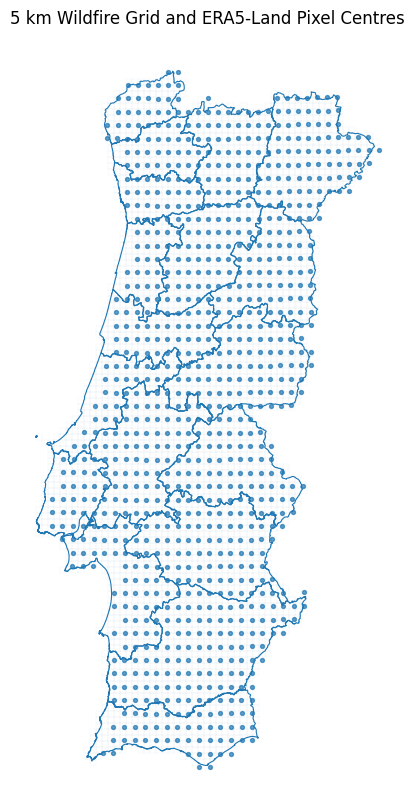

In [12]:
ax = districts.boundary.plot(
    figsize=(7, 10),
    linewidth=0.8
)

grid_5km_portugal.boundary.plot(
    ax=ax,
    linewidth=0.08,
    alpha=0.25
)

era5_pixels_used.plot(
    ax=ax,
    markersize=8,
    alpha=0.7
)

ax.set_title(
    "5 km Wildfire Grid and ERA5-Land Pixel Centres"
)
ax.set_axis_off()

plt.show()

### 4.2 Nearest-pixel distance audit

The second and final visual checks how far a cell's representative land point is from its assigned ERA5-Land pixel.

In the validated mapping:

- **962 unique ERA5-Land pixels** represent all 3,822 wildfire cells;
- only **19 cells with at least 50% land** are more than 10 km from their assigned pixel;
- among those 19 cells, the maximum distance is approximately **12.82 km**.

The mapping therefore provides complete weather coverage without altering the 5 km prediction grid.

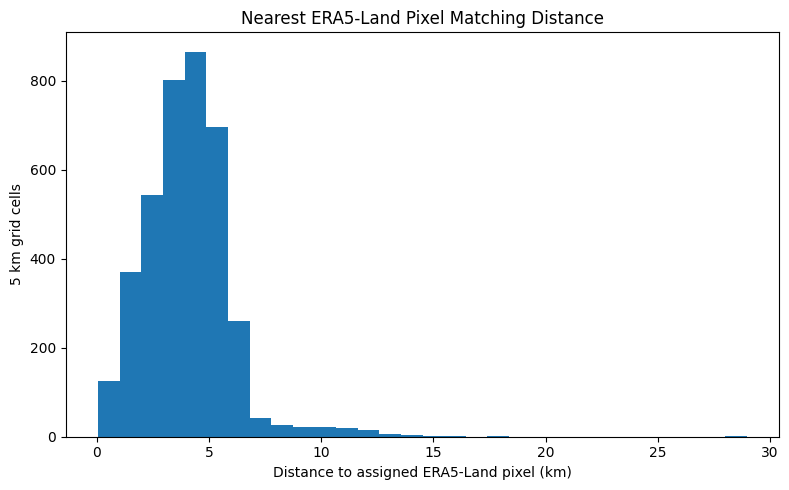

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(
    cell_era5_mapping[
        "distance_km"
    ],
    bins=30
)

plt.xlabel(
    "Distance to assigned ERA5-Land pixel (km)"
)
plt.ylabel("5 km grid cells")
plt.title(
    "Nearest ERA5-Land Pixel Matching Distance"
)
plt.tight_layout()
plt.show()

In [14]:
far_mostly_land = (
    cell_era5_mapping[
        (
            cell_era5_mapping[
                "distance_km"
            ] > 10
        )
        & (
            cell_era5_mapping[
                "land_fraction"
            ] >= 0.5
        )
    ]
    .copy()
)

print(
    "Cells > 10 km and >=50% land:",
    len(far_mostly_land)
)

print(
    far_mostly_land[
        "distance_km"
    ].describe()
)

cell_era5_mapping.to_parquet(
    "../data/interim/cell_era5_mapping.parquet",
    index=False
)

Cells > 10 km and >=50% land: 19
count    19.000000
mean     11.306096
std       0.777931
min      10.002943
25%      10.647954
50%      11.235332
75%      11.811768
max      12.819819
Name: distance_km, dtype: float64


In [15]:
era5_features = []

for _, row in (
    era5_pixels_used.iterrows()
):
    feature = ee.Feature(
        ee.Geometry.Point([
            row["longitude"],
            row["latitude"]
        ]),
        {
            "era5_pixel_id":
                row["era5_pixel_id"]
        }
    )

    era5_features.append(
        feature
    )

era5_pixels_ee = (
    ee.FeatureCollection(
        era5_features
    )
)

print(
    "ERA5 pixels in Earth Engine:",
    era5_pixels_ee
    .size()
    .getInfo()
)

ERA5 pixels in Earth Engine: 962


## 5. Annual weather extraction

The base modelling table contains **229 reference weeks**. Extracting 3,822 cells × 229 weeks separately would repeat the same Earth Engine calculations many times.

The optimized extraction therefore operates on the **962 unique weather pixels**, grouped by year.

For each year:

1. build each weekly 16-band image;
2. prefix every band with its reference date;
3. combine all weekly images into one wide yearly image;
4. sample the 962 ERA5 pixel locations once;
5. export one CSV.

This avoids the concurrent-aggregation problems encountered with a week-by-week extraction.

In [16]:
model_dataset = pd.read_parquet(
    "../data/interim/model_dataset_weekly.parquet"
)

reference_dates = (
    model_dataset[
        "reference_date"
    ]
    .drop_duplicates()
    .sort_values()
)

YEARS = sorted(
    reference_dates
    .dt.year
    .unique()
    .tolist()
)

N_ERA5_PIXELS = (
    era5_pixels_used[
        "era5_pixel_id"
    ]
    .nunique()
)

print("Years:", YEARS)
print(
    "ERA5 pixels:",
    N_ERA5_PIXELS
)
print(
    "Reference weeks:",
    len(reference_dates)
)

print(
    reference_dates
    .dt.year
    .value_counts()
    .sort_index()
)

Years: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
ERA5 pixels: 962
Reference weeks: 229
reference_date
2017    26
2018    25
2019    25
2020    25
2021    26
2022    26
2023    26
2024    25
2025    25
Name: count, dtype: int64


In [17]:
def build_yearly_weather_image(
    year,
    reference_dates
):
    year_dates = (
        reference_dates[
            reference_dates.dt.year
            == year
        ]
        .dt.strftime(
            "%Y-%m-%d"
        )
        .tolist()
    )

    yearly_image = None

    for date in year_dates:
        weekly_image = (
            build_weekly_weather_image(
                date
            )
        )

        date_prefix = (
            date.replace("-", "")
        )

        new_band_names = (
            weekly_image
            .bandNames()
            .map(
                lambda band: (
                    ee.String(
                        date_prefix
                    )
                    .cat("__")
                    .cat(
                        ee.String(band)
                    )
                )
            )
        )

        weekly_image = (
            weekly_image
            .rename(
                new_band_names
            )
        )

        if yearly_image is None:
            yearly_image = (
                weekly_image
            )
        else:
            yearly_image = (
                yearly_image
                .addBands(
                    weekly_image
                )
            )

    return yearly_image


def export_yearly_weather(
    year,
    reference_dates
):
    yearly_image = (
        build_yearly_weather_image(
            year,
            reference_dates
        )
    )

    yearly_sample = (
        yearly_image
        .sampleRegions(
            collection=era5_pixels_ee,
            properties=[
                "era5_pixel_id"
            ],
            scale=11132,
            geometries=False
        )
    )

    task = (
        ee.batch.Export.table
        .toDrive(
            collection=yearly_sample,
            description=
                f"era5_weather_{year}",
            folder=
                "wildfire_risk_portugal",
            fileNamePrefix=
                f"era5_weather_{year}",
            fileFormat="CSV"
        )
    )

    task.start()

    return task

### Optional export cell

The annual Earth Engine exports are a side-effect and may take time. They should only be launched when the CSVs need to be regenerated.

Set `RUN_EXPORTS = True` intentionally before running the following cell.

In [18]:
RUN_EXPORTS = False

weather_tasks = {}

if RUN_EXPORTS:
    for year in YEARS:
        task = export_yearly_weather(
            year,
            reference_dates
        )

        weather_tasks[year] = (
            task
        )

        print(
            year,
            task.status()["state"]
        )
else:
    print(
        "Exports not started. "
        "Set RUN_EXPORTS = True to regenerate them."
    )

Exports not started. Set RUN_EXPORTS = True to regenerate them.


## 6. Reshape and validate annual exports

The exported yearly files are wide: date and feature are encoded in each band name.

They are reshaped to:

> **ERA5 pixel × reference date**

Every annual file is checked for:

- expected number of rows;
- expected unique pixels;
- expected unique weeks;
- duplicate pixel-week pairs;
- missing values.

The original validated exports passed all checks for 2017–2025.

In [19]:
def wide_weather_to_long(
    weather_df
):
    weather_columns = [
        col
        for col in weather_df.columns
        if "__" in col
    ]

    weather_long = (
        weather_df[
            [
                "era5_pixel_id"
            ]
            + weather_columns
        ]
        .melt(
            id_vars="era5_pixel_id",
            var_name="date_feature",
            value_name="value"
        )
    )

    weather_long[
        [
            "reference_date",
            "feature"
        ]
    ] = (
        weather_long[
            "date_feature"
        ]
        .str.split(
            "__",
            n=1,
            expand=True
        )
    )

    weather_long[
        "reference_date"
    ] = pd.to_datetime(
        weather_long[
            "reference_date"
        ],
        format="%Y%m%d"
    )

    weather_long = (
        weather_long
        .pivot(
            index=[
                "era5_pixel_id",
                "reference_date"
            ],
            columns="feature",
            values="value"
        )
        .reset_index()
    )

    weather_long.columns.name = None

    return weather_long

In [22]:
all_weather_years = []

for year in YEARS:
    file_path = (
        f"../data/interim/"
        f"era5_weather_{year}.parquet"
    )

    weather_long = pd.read_parquet(
        file_path
    )

    expected_weeks = (
        reference_dates
        .dt.year
        .eq(year)
        .sum()
    )

    expected_rows = (
        expected_weeks
        * N_ERA5_PIXELS
    )

    duplicates = (
        weather_long[
            [
                "era5_pixel_id",
                "reference_date"
            ]
        ]
        .duplicated()
        .sum()
    )

    missing = (
        weather_long
        .isna()
        .sum()
        .sum()
    )

    print(
        year,
        "| weeks:",
        expected_weeks,
        "| rows:",
        len(weather_long),
        "| expected:",
        expected_rows,
        "| duplicates:",
        duplicates,
        "| missing:",
        missing
    )

    assert len(weather_long) == expected_rows
    assert weather_long["era5_pixel_id"].nunique() == N_ERA5_PIXELS
    assert weather_long["reference_date"].nunique() == expected_weeks
    assert duplicates == 0
    assert missing == 0

    all_weather_years.append(
        weather_long
    )

2017 | weeks: 26 | rows: 25012 | expected: 25012 | duplicates: 0 | missing: 0
2018 | weeks: 25 | rows: 24050 | expected: 24050 | duplicates: 0 | missing: 0
2019 | weeks: 25 | rows: 24050 | expected: 24050 | duplicates: 0 | missing: 0
2020 | weeks: 25 | rows: 24050 | expected: 24050 | duplicates: 0 | missing: 0
2021 | weeks: 26 | rows: 25012 | expected: 25012 | duplicates: 0 | missing: 0
2022 | weeks: 26 | rows: 25012 | expected: 25012 | duplicates: 0 | missing: 0
2023 | weeks: 26 | rows: 25012 | expected: 25012 | duplicates: 0 | missing: 0
2024 | weeks: 25 | rows: 24050 | expected: 24050 | duplicates: 0 | missing: 0
2025 | weeks: 25 | rows: 24050 | expected: 24050 | duplicates: 0 | missing: 0


In [23]:
era5_weather_weekly = (
    pd.concat(
        all_weather_years,
        ignore_index=True
    )
    .sort_values(
        [
            "reference_date",
            "era5_pixel_id"
        ]
    )
    .reset_index(drop=True)
)

print(
    "Final ERA5 table:",
    era5_weather_weekly.shape
)
print(
    "Unique pixels:",
    era5_weather_weekly[
        "era5_pixel_id"
    ].nunique()
)
print(
    "Unique weeks:",
    era5_weather_weekly[
        "reference_date"
    ].nunique()
)
print(
    "Duplicate pixel-week pairs:",
    era5_weather_weekly[
        [
            "era5_pixel_id",
            "reference_date"
        ]
    ].duplicated().sum()
)
print(
    "Missing values:",
    era5_weather_weekly
    .isna()
    .sum()
    .sum()
)

era5_weather_weekly.to_parquet(
    "../data/interim/era5_weather_weekly.parquet",
    index=False
)

Final ERA5 table: (220298, 18)
Unique pixels: 962
Unique weeks: 229
Duplicate pixel-week pairs: 0
Missing values: 0


The validated combined weather table contains:

- **220,298 ERA5 pixel-week rows**
- **962 unique pixels**
- **229 reference weeks**
- **0 duplicate pixel-week pairs**
- **0 missing values**

## 7. Map weather back to the 5 km wildfire grid

In [24]:
cell_weather_mapping = (
    cell_era5_mapping[
        [
            "cell_id",
            "era5_pixel_id",
            "distance_km"
        ]
    ]
    .copy()
)

weather_grid_weekly = (
    cell_weather_mapping
    .merge(
        era5_weather_weekly,
        on="era5_pixel_id",
        how="left"
    )
)

print(
    "Grid-weather shape:",
    weather_grid_weekly.shape
)
print(
    "Unique cells:",
    weather_grid_weekly[
        "cell_id"
    ].nunique()
)
print(
    "Unique weeks:",
    weather_grid_weekly[
        "reference_date"
    ].nunique()
)
print(
    "Duplicate cell-week pairs:",
    weather_grid_weekly[
        [
            "cell_id",
            "reference_date"
        ]
    ].duplicated().sum()
)
print(
    "Missing values:",
    weather_grid_weekly
    .isna()
    .sum()
    .sum()
)

weather_grid_weekly.to_parquet(
    "../data/interim/weather_grid_weekly.parquet",
    index=False
)

Grid-weather shape: (875238, 20)
Unique cells: 3822
Unique weeks: 229
Duplicate cell-week pairs: 0
Missing values: 0


The validated mapping expands the 962-pixel weather table back to **875,238 cell-week observations** with no duplicate `cell_id × reference_date` pairs and no missing weather values.

## 8. Merge weather with the wildfire target

In [25]:
model_dataset_weather = (
    model_dataset
    .merge(
        weather_grid_weekly,
        on=[
            "cell_id",
            "reference_date"
        ],
        how="left",
        validate="one_to_one"
    )
)

weather_features = [
    col
    for col in era5_weather_weekly.columns
    if col not in [
        "era5_pixel_id",
        "reference_date"
    ]
]

print(
    "Final shape:",
    model_dataset_weather.shape
)
print(
    "Unique cells:",
    model_dataset_weather[
        "cell_id"
    ].nunique()
)
print(
    "Unique weeks:",
    model_dataset_weather[
        "reference_date"
    ].nunique()
)
print(
    "Duplicate cell-week pairs:",
    model_dataset_weather[
        [
            "cell_id",
            "reference_date"
        ]
    ].duplicated().sum()
)
print(
    "Missing weather values:",
    model_dataset_weather[
        weather_features
    ]
    .isna()
    .sum()
    .sum()
)

print(
    "\nTarget distribution:"
)
print(
    model_dataset_weather[
        "fire_next_7_days"
    ].value_counts()
)

Final shape: (875238, 25)
Unique cells: 3822
Unique weeks: 229
Duplicate cell-week pairs: 0
Missing weather values: 0

Target distribution:
fire_next_7_days
0    825098
1     50140
Name: count, dtype: int64


In [26]:
model_dataset_weather.to_parquet(
    "../data/interim/model_dataset_weather.parquet",
    index=False
)

## 9. Final output and frozen decisions

Final weather-enriched dataset:

- **875,238 cell-week observations**
- **3,822 wildfire grid cells**
- **229 weekly reference dates**
- **16 antecedent weather features**
- **962 unique ERA5-Land pixels**
- **0 missing weather feature values**
- **0 duplicate cell-week rows**

Frozen weather methodology:

- source: `ECMWF/ERA5_LAND/DAILY_AGGR`
- all windows end before `reference_date`
- spatial prediction unit remains 5 × 5 km
- weather source is the nearest valid ERA5-Land pixel to a representative land point
- spatial matching distance is retained for traceability
- annual extraction is performed once per unique ERA5 pixel, not once per wildfire cell
- yearly exports are validated before being combined

The next notebook adds Sentinel-2 vegetation state and vegetation-trend information to the same `cell_id × reference_date` table.